In [1]:
import os, re, torch

OUTPUTS_DIR = "../outputs"
RUN_TYPE = "norm_analysis"
STEP = 0

def load_checkpoints(outputs_dir, run_type, step):
    checkpoints = {}
    for root, dirs, files in os.walk(outputs_dir):
        for fname in files:
            if fname.endswith(f"step-{step}.pt") and run_type in root:
                match = re.search(r"trained_(\w+_\d+)_step-(\d+)\.pt", fname)
                if not match:
                    continue
                model_key = match.group(1)
                step = match.group(2)
                full_key = model_key
                fpath = os.path.join(root, fname)
                checkpoints[full_key] = torch.load(fpath, map_location="cpu")
    return checkpoints

checkpoints = load_checkpoints(OUTPUTS_DIR, RUN_TYPE, STEP)

print(f"Loaded {len(checkpoints)} checkpoints")

/tmp/ipykernel_3599862/4293170589.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoints[full_key] = torch.load(fpath, map_location="cpu")


Loaded 12 checkpoints


In [2]:
import re
import torch
import torch.nn.functional as F
from typing import Dict, List, Tuple, Callable, Optional

def _collect_seed_grads(checkpoints: Dict, model_prefix: str) -> Tuple[List[Dict[str, torch.Tensor]], List[str]]:
    """
    From a checkpoints dict, collect all grads_state_dicts for keys starting with f"{model_prefix}_".
    Sort them by the trailing integer seed if present.
    Returns (list_of_grad_state_dicts, list_of_labels).
    """
    items = []
    pat = re.compile(rf"^{re.escape(model_prefix)}_(\d+)$")
    for k in checkpoints.keys():
        m = pat.match(k)
        if m and 'grads_state_dict' in checkpoints[k]:
            seed = int(m.group(1))
            items.append((seed, k))
    items.sort(key=lambda x: x[0])

    grad_dicts = [checkpoints[k]['grads_state_dict'] for _, k in items]
    labels = [f"{model_prefix}_{seed}" for seed, _ in items]
    return grad_dicts, labels

def _per_param_cosine_mats(grad_state_dicts: List[Dict[str, torch.Tensor]]):
    """
    Build cosine similarity matrices per parameter across seeds.
    Returns: dict param_name -> (C, used_seed_indices)
    """
    all_param_names = set().union(*[d.keys() for d in grad_state_dicts])
    result = {}
    for pname in sorted(all_param_names):
        vecs, idxs = [], []
        for i, gs in enumerate(grad_state_dicts):
            g = gs.get(pname, None)
            if g is not None:
                vecs.append(g.flatten())
                idxs.append(i)
        if len(vecs) < 2:
            continue
        V = torch.stack(vecs, dim=0)
        V = F.normalize(V, p=2, dim=1, eps=1e-12)
        C = V @ V.t()  # cosine matrix
        result[pname] = (C, idxs)
    return result

def _reduce_pairwise(C: torch.Tensor, how: str = "mean") -> float:
    """
    Reduce an NxN cosine matrix to a single scalar using only off-diagonal pairs.
    how: "mean", "max", "median"
    """
    n = C.shape[0]
    if n < 2:
        return float('nan')
    # take upper triangle off-diagonal
    iu = torch.triu_indices(n, n, offset=1)
    vals = C[iu[0], iu[1]]
    if how == "mean":
        return vals.mean().item()
    elif how == "max":
        return vals.max().item()
    elif how == "median":
        return vals.median().item()
    else:
        raise ValueError(f"Unknown reducer '{how}'")

def default_type_group(pname: str) -> str:
    """
    Default parameter-type grouper: use suffix after last '.' (e.g., 'weight', 'bias').
    If no dot, return the whole name.
    """
    return pname.split('.')[-1]

def summarize_grad_alignment(
    checkpoints: Dict,
    model: str = "wmlp",                 # "mlp" | "wmlp" | "sigmlp"
    reducer: str = "mean",               # "mean" | "max" | "median"
    type_grouper: Optional[Callable[[str], str]] = None,
):
    """
    Returns:
      per_param_scores: Dict[param_name] -> float (aggregated pairwise cosine across seeds)
      per_type_scores:  Dict[type_name]  -> float (mean of per_param_scores within type)
      meta: dict with labels, counts, etc.
    """
    if type_grouper is None:
        type_grouper = default_type_group

    grad_dicts, labels = _collect_seed_grads(checkpoints, model_prefix=model)
    if len(grad_dicts) < 2:
        raise ValueError(f"Found <2 seeds for model '{model}'. Need at least two to compare.")

    per_param_mats = _per_param_cosine_mats(grad_dicts)

    # reduce to one number per parameter
    per_param_scores = {}
    for pname, (C, idxs) in per_param_mats.items():
        per_param_scores[pname] = _reduce_pairwise(C, how=reducer)

    # aggregate per type
    buckets: Dict[str, List[float]] = {}
    for pname, score in per_param_scores.items():
        t = type_grouper(pname)
        buckets.setdefault(t, []).append(score)

    per_type_scores = {t: float(torch.tensor(v).mean().item()) for t, v in buckets.items()}

    meta = {
        "seeds_compared": labels,
        "num_params_used": len(per_param_scores),
        "reducer": reducer,
        "model": model,
    }
    return per_param_scores, per_type_scores, meta

In [3]:
def summarize_grad_norms(
    checkpoints: Dict,
    model: str = "wmlp",                 # "mlp" | "wmlp" | "sigmlp"
    reducer: str = "mean",               # "mean" | "max" | "median"
    type_grouper: Optional[Callable[[str], str]] = None,
):
    """
    Compute gradient norms (L2) across seeds.
    Returns:
      per_param_norms: Dict[param_name] -> float (aggregated norm across seeds)
      per_type_norms:  Dict[type_name]  -> float (mean of per_param_norms within type)
      meta: dict with labels, counts, etc.
    """
    if type_grouper is None:
        type_grouper = default_type_group

    grad_dicts, labels = _collect_seed_grads(checkpoints, model_prefix=model)
    if len(grad_dicts) == 0:
        raise ValueError(f"Found no grads for model '{model}'.")

    # collect raw norms for each parameter across seeds
    all_param_names = set().union(*[d.keys() for d in grad_dicts])
    per_param_norms: Dict[str, float] = {}

    for pname in sorted(all_param_names):
        vals = []
        for gs in grad_dicts:
            g = gs.get(pname, None)
            if g is not None:
                vals.append(g.norm().item())
        if len(vals) == 0:
            continue
        tvals = torch.tensor(vals, dtype=torch.float32)
        if reducer == "mean":
            per_param_norms[pname] = tvals.mean().item()
        elif reducer == "max":
            per_param_norms[pname] = tvals.max().item()
        elif reducer == "median":
            per_param_norms[pname] = tvals.median().item()
        else:
            raise ValueError(f"Unknown reducer '{reducer}'")

    # aggregate per type
    buckets: Dict[str, List[float]] = {}
    for pname, score in per_param_norms.items():
        t = type_grouper(pname)
        buckets.setdefault(t, []).append(score)

    per_type_norms = {t: float(torch.tensor(v).mean().item()) for t, v in buckets.items()}

    meta = {
        "seeds_compared": labels,
        "num_params_used": len(per_param_norms),
        "reducer": reducer,
        "model": model,
    }
    return per_param_norms, per_type_norms, meta

In [4]:
per_param, per_type, meta = summarize_grad_alignment(
    checkpoints,
    model="wmlp_layernorm",
    reducer="mean",
)
per_param

{'lins.0.bias': 0.7780808806419373,
 'lins.0.weight': 0.7902081608772278,
 'lins.1.bias': 0.7891214489936829,
 'lins.1.weight': 0.7866582274436951,
 'lins.2.bias': 0.8723618388175964,
 'lins.2.weight': 0.8449587821960449,
 'lins.3.bias': 0.9425520896911621,
 'lins.3.weight': 0.8705126643180847,
 'norms.0.bias': 0.7845123410224915,
 'norms.0.weight': 0.7660093307495117,
 'norms.1.bias': 0.7883865237236023,
 'norms.1.weight': 0.7796556353569031,
 'norms.2.bias': 0.8765618801116943,
 'norms.2.weight': 0.8656306266784668}

In [5]:
per_param, per_type, meta = summarize_grad_norms(
    checkpoints,
    model="wmlp_layernorm_linear",
    reducer="mean",
)
per_param

{'lins.0.bias': 1.3416377305984497,
 'lins.0.weight': 35.785064697265625,
 'lins.1.bias': 1.8117130994796753,
 'lins.1.weight': 26.501001358032227,
 'lins.2.bias': 5.475856304168701,
 'lins.2.weight': 51.50056838989258,
 'lins.3.bias': 9.631972312927246,
 'lins.3.weight': 39.511383056640625}

In [6]:
per_param, per_type, meta = summarize_grad_norms(
    checkpoints,
    model="mlp_layernorm",
    reducer="mean",
)
per_param

{'lins.0.bias': 7.533735275268555,
 'lins.0.weight': 197.49176025390625,
 'lins.1.bias': 10.091408729553223,
 'lins.1.weight': 155.6117401123047,
 'lins.2.bias': 9.464524269104004,
 'lins.2.weight': 149.37203979492188,
 'lins.3.bias': 8.371220588684082,
 'lins.3.weight': 141.9708251953125,
 'norms.0.bias': 7.033137798309326,
 'norms.0.weight': 7.797909259796143,
 'norms.1.bias': 6.61912727355957,
 'norms.1.weight': 7.473800182342529,
 'norms.2.bias': 6.157810211181641,
 'norms.2.weight': 7.241970062255859}

In [8]:
def collect_unique_steps(outputs_dir, run_type):
    steps = set()
    for root, dirs, files in os.walk(outputs_dir):
        for fname in files:
            if fname.endswith(".pt") and run_type in root:
                match = re.search(r"step-(\d+)\.pt", fname)
                if match:
                    steps.add(int(match.group(1)))
    return sorted(steps)

unique_steps = collect_unique_steps(OUTPUTS_DIR, RUN_TYPE)

In [9]:
from tqdm import tqdm

grad_alignment = {step: {'mlp_layernorm': None, 'mlp_layernorm_linear': None, 'wmlp_layernorm': None, 'wmlp_layernorm_linear': None} for step in unique_steps}

for step in tqdm(unique_steps):
    for model in grad_alignment[step].keys():
        grad_alignment[step][model] = summarize_grad_alignment(
            load_checkpoints(OUTPUTS_DIR, RUN_TYPE, step),
            model=model,
            reducer='mean',
        )

  0%|          | 0/338 [00:00<?, ?it/s]/tmp/ipykernel_3599862/4293170589.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoints[full_key] = torch.load(fpath, map_l

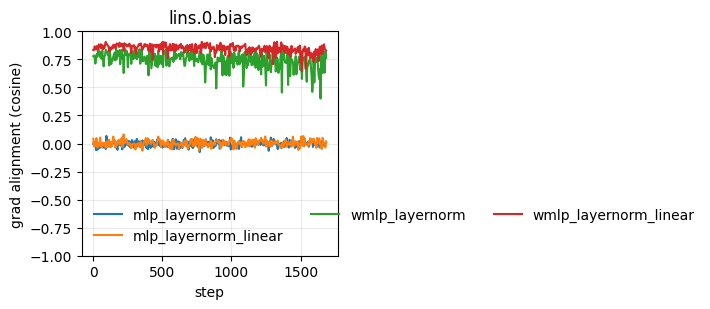

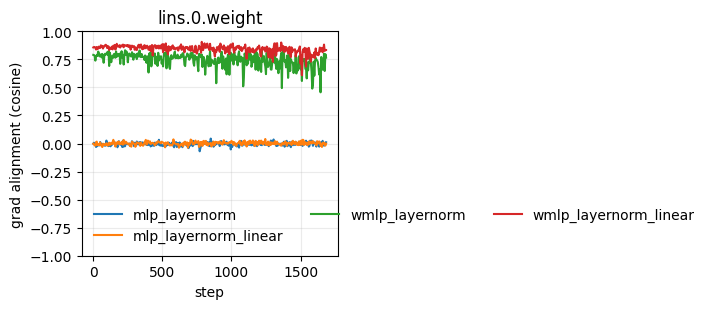

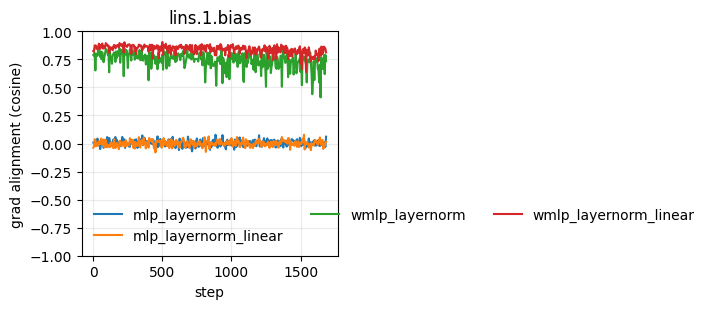

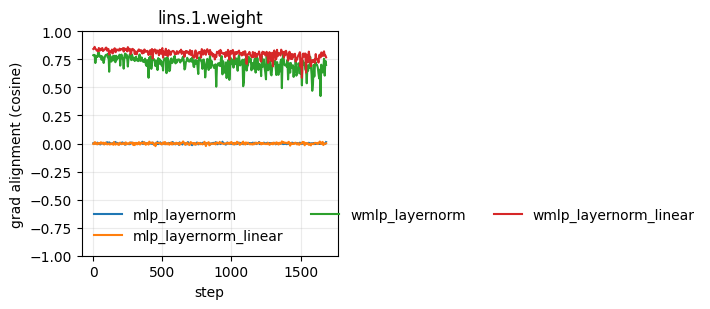

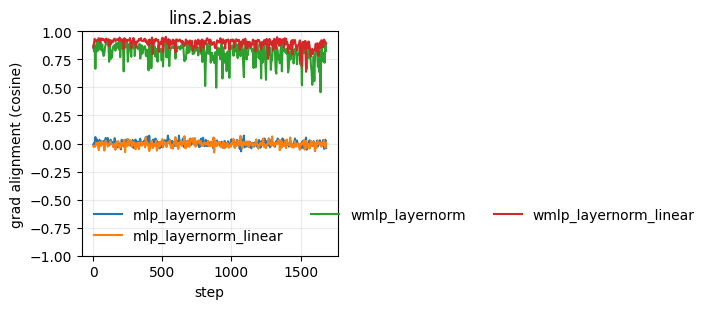

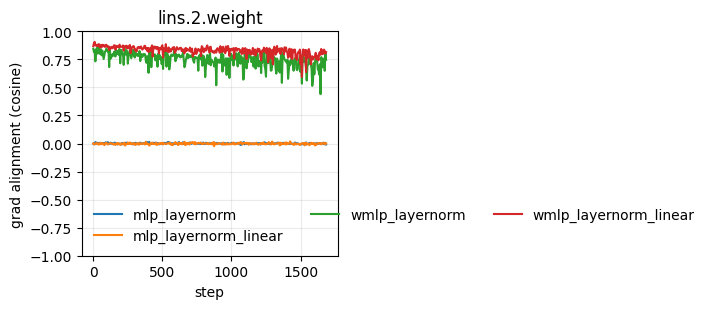

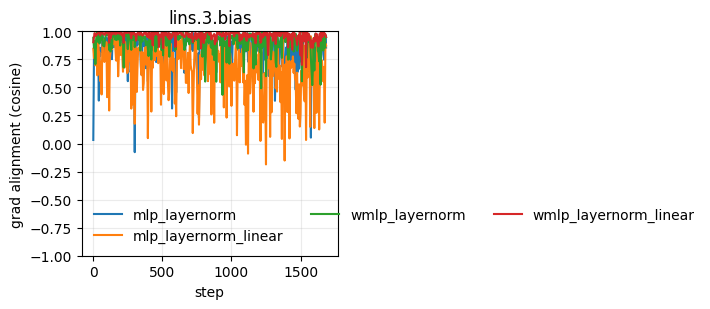

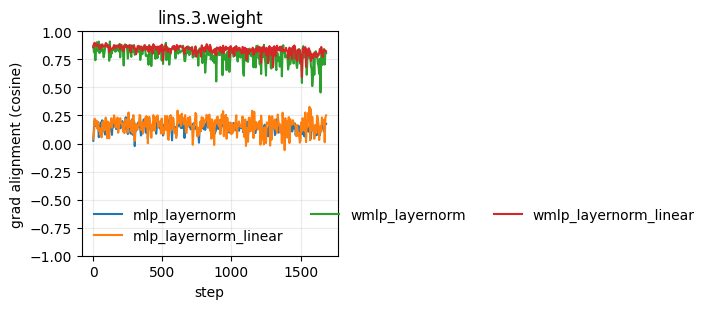

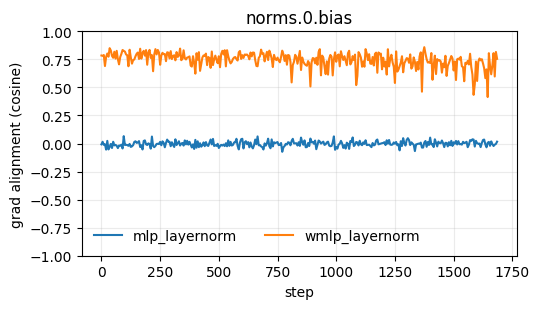

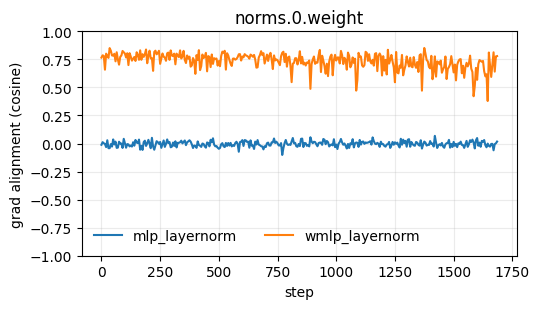

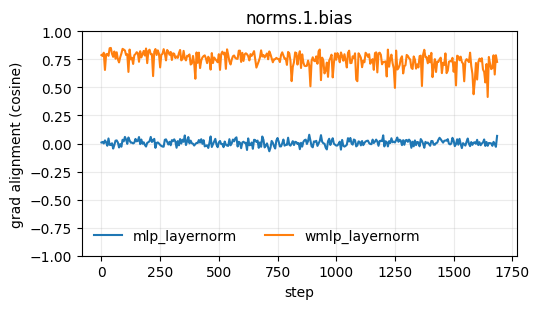

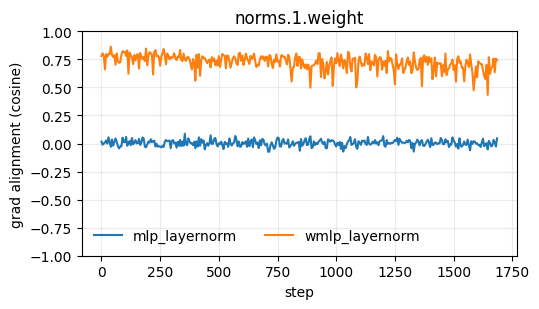

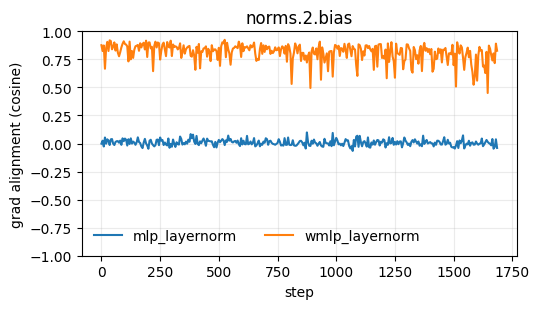

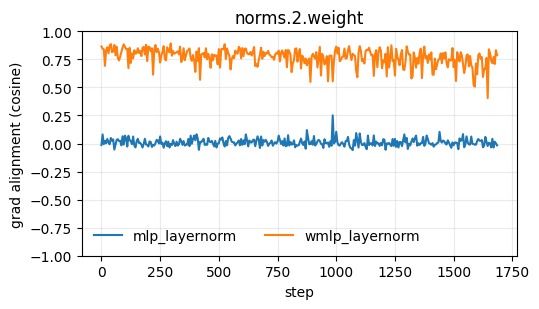

In [12]:
import os
import re
import math
import numpy as np
import matplotlib.pyplot as plt

def _safe_fname(s: str) -> str:
    s = re.sub(r"[^\w\-_.]+", "_", s)
    return s[:200]

def extract_param_timecourses(grad_alignment, models=("mlp","wmlp0","wmlp","sigmlp")):
    """
    grad_alignment: dict[step][model] = (per_param, per_type, meta)
    Returns:
      steps_sorted: list[int]
      params_sorted: list[str]
      values: dict[param][model] -> np.array shape (len(steps_sorted),) with NaNs for missing
    """
    steps_sorted = sorted(grad_alignment.keys())
    # collect all parameter names that ever appear in any model at any step
    all_params = set()
    for s in steps_sorted:
        for m in models:
            if grad_alignment[s].get(m) is None:
                continue
            per_param, _, _ = grad_alignment[s][m]
            all_params.update(per_param.keys())
    params_sorted = sorted(all_params)

    # build series
    values = {p: {m: np.full(len(steps_sorted), np.nan, dtype=float) for m in models}
              for p in params_sorted}

    for si, s in enumerate(steps_sorted):
        for m in models:
            if grad_alignment[s].get(m) is None:
                continue
            per_param, _, _ = grad_alignment[s][m]
            for p, v in per_param.items():
                values[p][m][si] = v

    return steps_sorted, params_sorted, values

def plot_param_timecourses(grad_alignment,
                           models=("mlp","wmlp","sigmlp"),
                           save_dir=None,
                           dpi=140,
                           ylim=(-1.0, 1.0),
                           show=True):
    """
    Creates one figure per parameter with curves for all models over steps.
    """
    steps_sorted, params_sorted, values = extract_param_timecourses(grad_alignment, models=models)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    # style
    model_styles = {
        "mlp":   dict(marker="o", linestyle="-", linewidth=1.5, markersize=3),
        "wmlp":  dict(marker="s", linestyle="-", linewidth=1.5, markersize=3),
        "sigmlp":dict(marker="^", linestyle="-", linewidth=1.5, markersize=3),
    }

    for p in params_sorted:
        plt.figure(figsize=(5.5, 3.2))
        has_any = False
        for m in models:
            y = values[p][m]
            if np.all(np.isnan(y)):
                continue
            has_any = True
            plt.plot(steps_sorted, y, label=m, **model_styles.get(m, {}))
        if not has_any:
            plt.close()
            continue

        plt.title(p)
        plt.xlabel("step")
        plt.ylabel("grad alignment (cosine)")
        if ylim is not None:
            plt.ylim(*ylim)
        plt.xscale("linear")
        plt.grid(True, alpha=0.25)
        plt.legend(frameon=False, ncol=min(len(models),3))
        plt.tight_layout()

        if save_dir:
            fname = os.path.join(save_dir, f"{_safe_fname(p)}.png")
            plt.savefig(fname, dpi=dpi)
        if show:
            plt.show()
        else:
            plt.close()

# --- usage ---
# grad_alignment[step][model] = (per_param: Dict[param->score], per_type: Dict[type->score], meta)
# e.g., after your search loop:
# grad_alignment = {step: {'mlp': (...), 'wmlp': (...), 'sigmlp': (...)} for step in unique_steps}

plot_param_timecourses(
    grad_alignment,
    models=("mlp_layernorm","mlp_layernorm_linear","wmlp_layernorm","wmlp_layernorm_linear"),
    save_dir="figs_grad_alignment_per_param",  # or None to not save
    dpi=160,
    ylim=(-1, 1),   # change to (0,1) if you only care about positive alignment
    show=True
)

In [11]:
import torch
import torch.nn.functional as F

def per_param_cosine_matrices(grad_state_dicts, model_labels=None):
    """
    grad_state_dicts: list of dicts, each like checkpoints['mlp_i']['grads_state_dict']
    model_labels: optional list of names (same length as grad_state_dicts) for readability
    Returns: dict {param_name: (NxN tensor cosine matrix, used_indices)}
             where used_indices are the indices of models that had a non-None grad for this param.
    """
    if model_labels is None:
        model_labels = [f"model_{i}" for i in range(len(grad_state_dicts))]

    # Only consider parameter names that appear in at least one dict
    all_param_names = set().union(*[d.keys() for d in grad_state_dicts])

    result = {}
    for pname in sorted(all_param_names):
        # Gather flattened grads for this parameter across models
        vecs = []
        used_idxs = []
        for i, gs in enumerate(grad_state_dicts):
            g = gs.get(pname, None)
            if g is not None:
                vecs.append(g.flatten())
                used_idxs.append(i)

        # If fewer than 2 models have this grad, skip (no matrix to compute)
        if len(vecs) < 2:
            continue

        V = torch.stack(vecs, dim=0)  # shape: (k, D)
        # Normalize rows, avoid divide-by-zero
        V = F.normalize(V, p=2, dim=1, eps=1e-12)

        # Cosine similarity matrix = V * V^T
        C = V @ V.t()  # shape: (k, k), symmetric, diag ~ 1

        # Store (matrix, indices); caller can map indices -> labels
        result[pname] = (C, used_idxs)

    return result, model_labels

# Example usage:
g0 = checkpoints['wmlp_0']['grads_state_dict']
g1 = checkpoints['wmlp_1']['grads_state_dict']
g2 = checkpoints['wmlp_2']['grads_state_dict']

per_param_mats, labels = per_param_cosine_matrices(
    [g0, g1, g2],
    model_labels=["wmlp_0", "wmlp_1", "wmlp_2"]
)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_param_heatmaps(per_param_mats, model_labels):
    """
    per_param_mats: dict from per_param_cosine_matrices
    model_labels: list of names (like ["mlp_0", "mlp_1", "mlp_2"])
    """
    n_params = len(per_param_mats)
    ncols = 3
    nrows = (n_params + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for idx, (pname, (C, used_idxs)) in enumerate(per_param_mats.items()):
        ax = axes[idx]
        names = [model_labels[i] for i in used_idxs]

        sns.heatmap(
            C.detach().cpu().numpy(),
            vmin=-1, vmax=1, cmap="coolwarm_r", annot=True,
            xticklabels=names, yticklabels=names,
            ax=ax, annot_kws={"size": 6}, cbar=False
        )
        ax.set_title(pname)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_param_heatmaps(per_param_mats, labels)


KeyError: 'wmlp_0'